
# Análisis Exploratorio de Datos y Modelo de Regresión Lineal  
 Proyecto: ComercioYA  

Autor: Martin Rojas
Fecha: 17/02/2026  

---

# Objetivo

El objetivo de este análisis es explorar el comportamiento de los clientes de ComercioYA,
identificar patrones relevantes y construir un modelo de regresión lineal que permita
explicar el gasto total de los clientes en función de variables de comportamiento.



# Importación de librerías

En esta sección se importan las librerías necesarias para el análisis de datos,
visualización y modelado estadístico.

In [233]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Generación del dataset

Dado que no se dispone de un dataset real, se generó un dataset sintético que simula el
comportamiento de clientes de una plataforma de comercio electrónico.

Las variables incluidas representan características típicas del comportamiento del cliente:

- Frecuencia de compra: número de compras realizadas
- Visitas: número de visitas al sitio web
- Compras total ($): gasto total del cliente
- Devoluciones: número de devoluciones realizadas
- Reseñas: calificación promedio del cliente
- Género: variable categórica del cliente

El dataset fue generado utilizando distribuciones estadísticas realistas con el fin de
replicar patrones plausibles observados en entornos de comercio electrónico.

Este enfoque permite aplicar técnicas de análisis exploratorio de datos (EDA) y modelado
de regresión en un entorno controlado.

* 1: Análisis Exploratorio de Datos 

Objetivo: Comprender el propósito del EDA y diferenciarlo del
análisis inicial.

In [234]:

# Fijar semilla para reproducibilidad
np.random.seed(42)
n = 200

# Generar número de visitas web por cliente
visitas_web = np.random.randint(1, 50, n)

# Generar compras basadas en visitas_web con variación aleatoria
compras = 0.35 * visitas_web + np.random.normal(2, 2, n)

# Generar monto_total basado en compras con variación
monto_total = 75 * compras + np.random.normal(0, 150, n)

# Asegurar que compras sean enteras y no negativas
compras = np.clip(compras, 0, None).round().astype(int)

# Generar devoluciones sin superar las compras
devoluciones = np.array([np.random.randint(0, c + 1) for c in compras])
devoluciones = np.clip(devoluciones, 0, (compras / 2).astype(int))

# Generar reseñas entre 1 y 5 con mayor probabilidad de valores altos
reseñas = np.random.choice([1,2,3,4,5], size=n, p=[0.05,0.05,0.1,0.5,0.3])

# Evitar valores negativos en monto_total
monto_total = np.clip(monto_total, 0, None)

# Generar variable categórica género
genero = np.random.choice(["Masculino", "Femenino"], size=n)



In [235]:

# Crear el DataFrame con las variables generadas
data = pd.DataFrame({
    "cliente_id": range(1, n+1),     # Crear identificador único para cada cliente
    "visitas_web": visitas_web,      # Número de visitas al sitio web
    "Compras": compras,              # Número de compras realizadas
    "monto_total": monto_total,      # Monto total gastado
    "devoluciones": devoluciones,    # Número de devoluciones
    "reseñas": reseñas,              # Calificación del cliente (1 a 5)
    "genero": genero,                # Género del cliente (variable categórica)
})

# Establecer cliente_id como índice del DataFrame
data.set_index("cliente_id", inplace=True)

# Redondear monto_total a 2 decimales
data["monto_total"] = data["monto_total"].round(2)

# Mostrar las primeras filas del dataset
data.head()

,visitas_web,Compras,monto_total,devoluciones,reseñas,genero
cliente_id,,,,,,
1,39,19,1648.33,9,5,Masculino
2,29,12,848.70,6,1,Masculino
3,15,8,664.45,4,4,Masculino
4,43,17,1237.25,8,5,Masculino
5,8,1,39.53,0,4,Femenino


In [ ]:
# Mostrar información general del DataFrame (tipo de datos y valores no nulos)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   visitas_web   200 non-null    int32  
 1   Compras       200 non-null    int64  
 2   monto_total   200 non-null    float64
 3   devoluciones  200 non-null    int64  
 4   reseñas       200 non-null    int64  
 5   genero        200 non-null    str    
dtypes: float64(1), int32(1), int64(3), str(1)
memory usage: 8.7 KB


# Clasificación de variables

El dataset contiene 200 registros y 6 variables, sin valores faltantes. La variable genero es categórica, ya que representa categorías de clientes. Las variables visitas_web, Compras, devoluciones y reseñas son cuantitativas discretas, ya que corresponden a conteos enteros. La variable monto_totales cuantitativa continua, ya que representa un valor monetario con valores decimales.

In [237]:
# Verificar cantidad de valores faltantes en cada columna
data.isnull().sum()

visitas_web     0
Compras         0
monto_total     0
devoluciones    0
reseñas         0
genero          0
dtype: int64

In [238]:
# Mostrar estadísticas descriptivas de las variables numéricas
data.describe()


,visitas_web,Compras,monto_total,devoluciones,reseñas
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24.995000,10.900000,821.343450,3.675000,4.045000
std,14.036384,5.451476,426.896118,2.781738,0.942026
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,13.000000,6.000000,479.320000,1.000000,4.000000
50%,25.500000,11.500000,855.395000,3.000000,4.000000
75%,37.000000,16.000000,1167.400000,6.000000,5.000000
max,49.000000,22.000000,1648.330000,10.000000,5.000000


# Detección de valores faltantes e inconsistencias (IDA)

Se realizó una revisión del dataset para identificar valores faltantes e inconsistencias. Mediante el uso de la función `isnull().sum()`, se confirmó que no existen valores faltantes en ninguna de las variables. Asimismo, el análisis descriptivo permitió verificar que no existen valores inconsistentes, como números negativos en monto_total o valores fuera de rango en reseñas. Por lo tanto, el dataset es válido y apto para el análisis exploratorio.


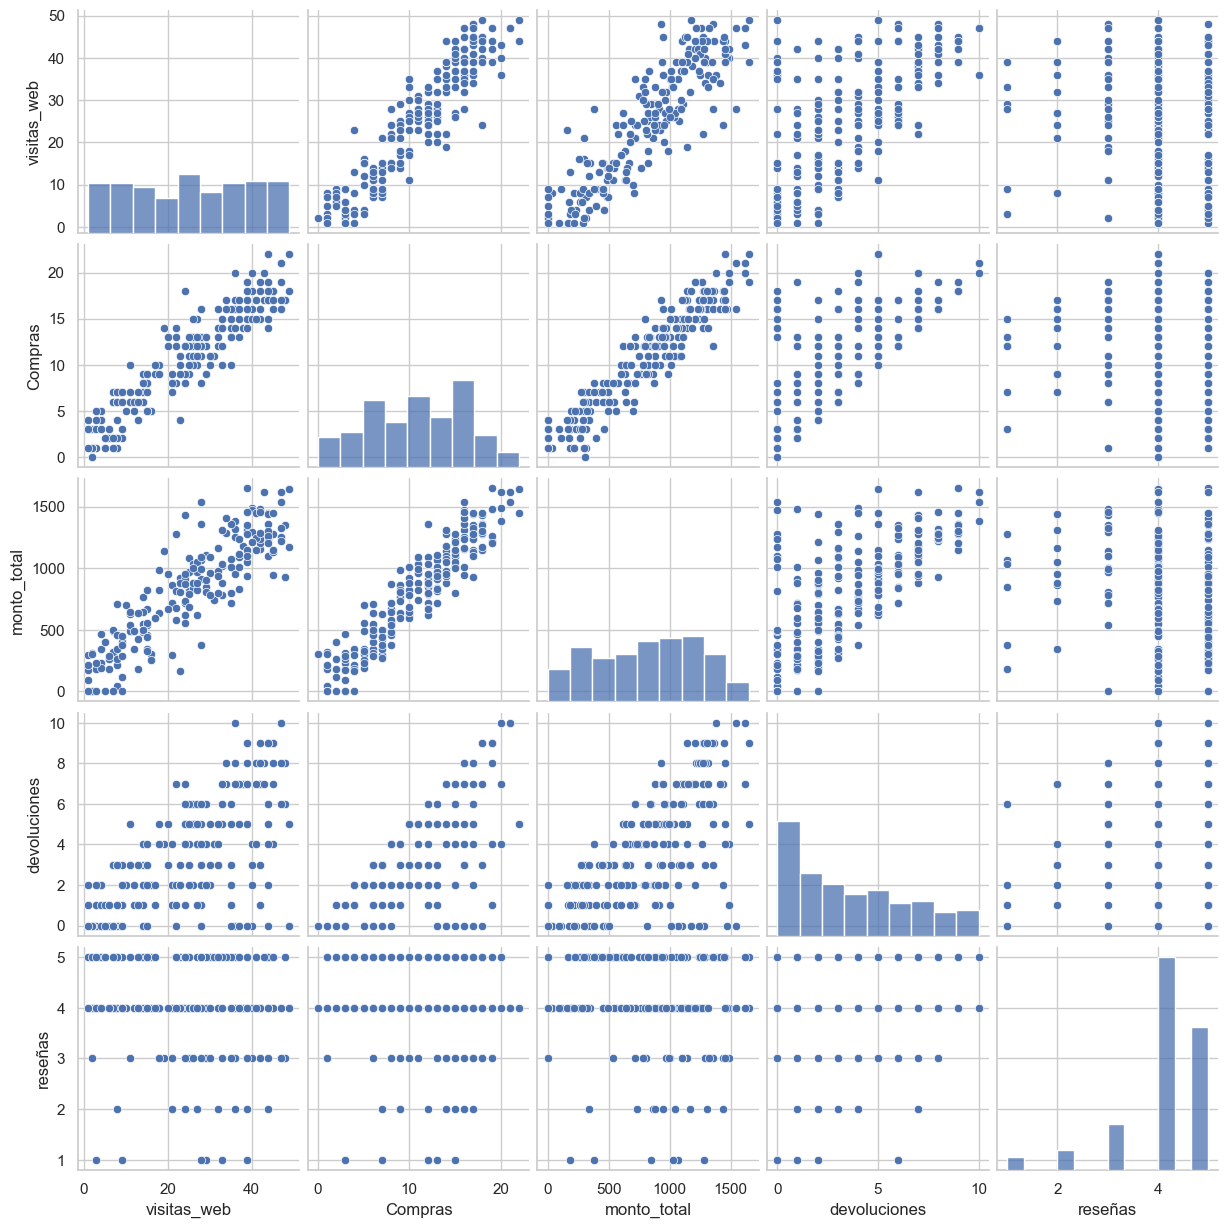

In [239]:
# Crear pairplot para visualizar relaciones entre variables
grafico = sns.pairplot(data)

# Mostrar el gráfico
plt.show()


# Exploración visual inicial de datos

Relación entre visitas web y compras:**  
Se observa una relación positiva clara entre el número de visitas web y la cantidad de compras realizadas. A medida que aumentan las visitas al sitio, las compras tienden a incrementarse.

La nube de puntos muestra una tendencia ascendente bien definida, lo que sugiere que el número de visitas es un factor importante para explicar el comportamiento de compra de los clientes.

---

Relación entre compras y monto total:**  
Existe una relación positiva fuerte entre la cantidad de compras y el monto total gastado. A mayor número de compras, el monto total aumenta de manera proporcional.

Esta relación es esperada, ya que el monto total depende directamente del número de productos adquiridos, lo que confirma la coherencia del dataset.

---

Relación entre visitas web y monto total:**  
También se observa una relación positiva entre las visitas web y el monto total gastado, aunque es ligeramente más dispersa que la relación entre compras y monto total.

Esto indica que un mayor número de visitas puede asociarse a un mayor gasto, pero la variable compras es un factor más determinante en el monto total.

---

Relación entre devoluciones y compras:**  
Se observa una relación positiva moderada entre el número de compras y las devoluciones. A medida que aumentan las compras, también aumenta la cantidad de devoluciones.

Esto es consistente con el comportamiento esperado, ya que un mayor volumen de compras incrementa la probabilidad de devoluciones.

---

Relación entre reseñas y otras variables:**  
La variable reseñas no muestra una relación lineal fuerte con las demás variables. La distribución indica que la mayoría de las reseñas se concentran en valores altos (4 y 5).

Esto sugiere que, en general, los clientes presentan un alto nivel de satisfacción, y que las reseñas no dependen directamente del número de compras, visitas o devoluciones.


#  2: Estadística Descriptiva

 Objetivo

En esta sección se aplican conceptos de estadística descriptiva para analizar las variables del dataset. Se calcularán medidas de tendencia central, dispersión y posición, y se utilizarán gráficos para visualizar la distribución de los datos e identificar posibles valores atípicos.


In [240]:
# Crear tabla de estadísticas descriptivas
tabla_estadistica = data.describe().T

# Agregar mediana, varianza y moda
tabla_estadistica["mediana"] = data.median(numeric_only=True)
tabla_estadistica["varianza"] = data.var(numeric_only=True)
tabla_estadistica["moda"] = data.mode(numeric_only=True).iloc[0]

# Mostrar tabla completa
tabla_estadistica


,count,mean,std,min,25%,50%,75%,max,mediana,varianza,moda
visitas_web,200.0,24.99500,14.036384,1.0,13.00,25.500,37.0,49.00,25.500,197.020075,44.0
Compras,200.0,10.90000,5.451476,0.0,6.00,11.500,16.0,22.00,11.500,29.718593,12.0
monto_total,200.0,821.34345,426.896118,0.0,479.32,855.395,1167.4,1648.33,855.395,182240.295199,0.0
devoluciones,200.0,3.67500,2.781738,0.0,1.00,3.000,6.0,10.00,3.000,7.738065,0.0
reseñas,200.0,4.04500,0.942026,1.0,4.00,4.000,5.0,5.00,4.000,0.887412,4.0


In [241]:
# Cuartiles (Q1, Q2, Q3)
data.quantile([0.25, 0.5, 0.75], numeric_only=True)


,visitas_web,Compras,monto_total,devoluciones,reseñas
0.25,13.0,6.0,479.320,1.0,4.0
0.50,25.5,11.5,855.395,3.0,4.0
0.75,37.0,16.0,1167.400,6.0,5.0


# Cuartiles y percentiles

Los cuartiles permiten dividir los datos en cuatro partes iguales, lo que facilita el análisis de la distribución. El primer cuartil (Q1) representa el 25% de los valores más bajos, el segundo cuartil corresponde a la mediana, y el tercer cuartil (Q3) representa el 75% de los valores.

Los percentiles permiten analizar con mayor precisión la posición relativa de los datos dentro de la distribución.


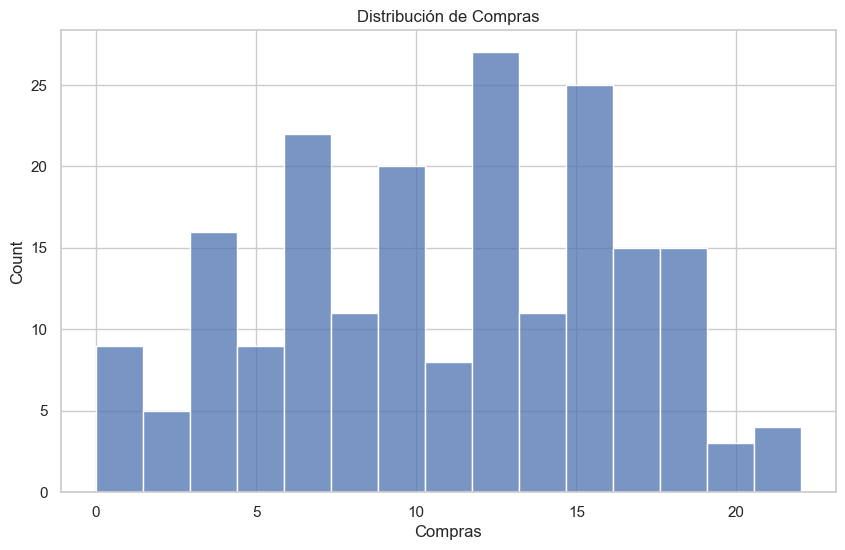

In [242]:
# Crear histograma para visualizar la distribución de Compras
sns.histplot(data["Compras"], bins=15)

# Agregar título al gráfico
plt.title("Distribución de Compras")

# Mostrar gráfico
plt.show()



# Análisis de la distribución de la variable Compras

El histograma muestra la distribución del número de compras realizadas por los clientes. Se observa que la mayor concentración de datos se encuentra aproximadamente entre 8 y 17 compras, lo que indica que la mayoría de los clientes realiza una cantidad moderada de compras.

La distribución presenta una forma relativamente equilibrada, sin una fuerte asimetría hacia valores bajos o altos. Esto sugiere que el comportamiento de compra está distribuido de manera bastante uniforme dentro del rango observado.

Asimismo, se identifican pocos clientes con valores extremos, tanto con muy pocas compras como con valores cercanos al máximo, lo que indica una variabilidad moderada en el comportamiento de compra.

En general, la variable Compras presenta una distribución adecuada para el análisis estadístico, sin evidencia clara de valores atípicos extremos que puedan afectar significativamente el análisis.


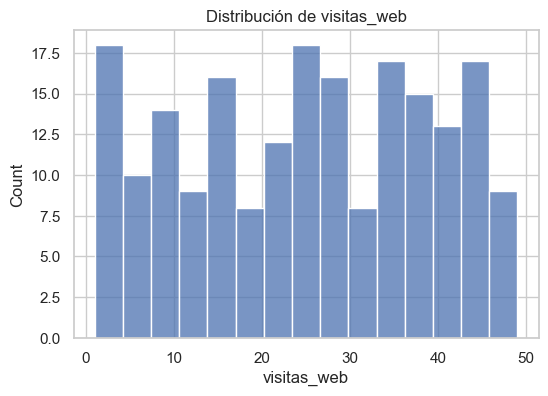

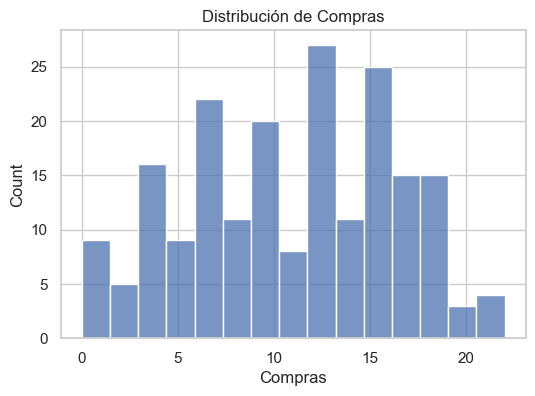

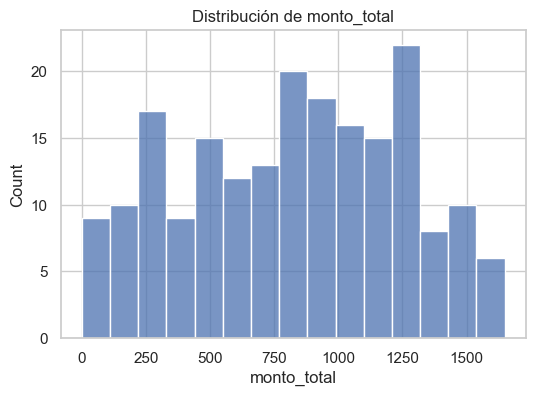

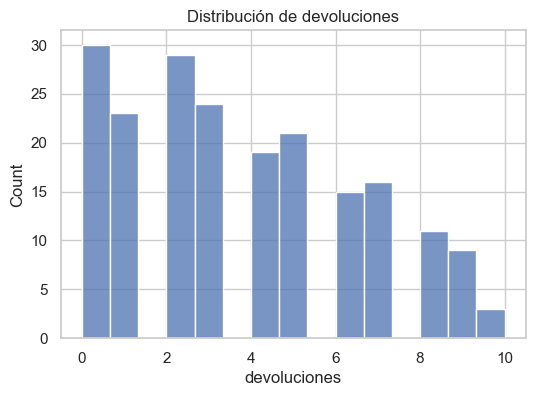

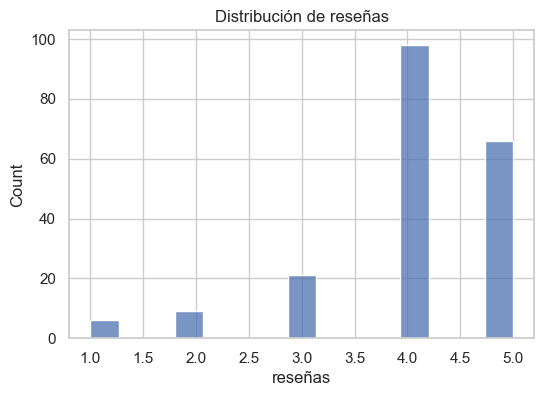

In [243]:
# Lista de variables numéricas a visualizar
variables = ["visitas_web", "Compras", "monto_total", "devoluciones", "reseñas"]

# Crear histogramas para cada variable
for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(data[var], bins=15)
    plt.title(f"Distribución de {var}")
    plt.show()


# Análisis de histogramas de variables cuantitativas

Distribución de visitas_web:  
Se observa una distribución relativamente uniforme de las visitas al sitio web, lo que indica que los clientes presentan distintos niveles de interacción con la plataforma.

Distribución de Compras:  
La mayor concentración de clientes se encuentra en niveles intermedios de compras, lo que indica un comportamiento de compra moderado en la mayoría de los casos.

Distribución de monto_total:
El monto total presenta una distribución coherente con la variable Compras, mostrando que los clientes con mayor número de compras tienden a registrar mayores niveles de gasto.

Distribución de devoluciones:
La mayoría de los clientes presenta un número bajo de devoluciones, lo cual es consistente con un comportamiento normal en sistemas de comercio electrónico.

Distribución de reseñas:
Las reseñas se concentran principalmente en valores altos, especialmente entre 4 y 5, lo que indica un alto nivel de satisfacción general de los clientes.


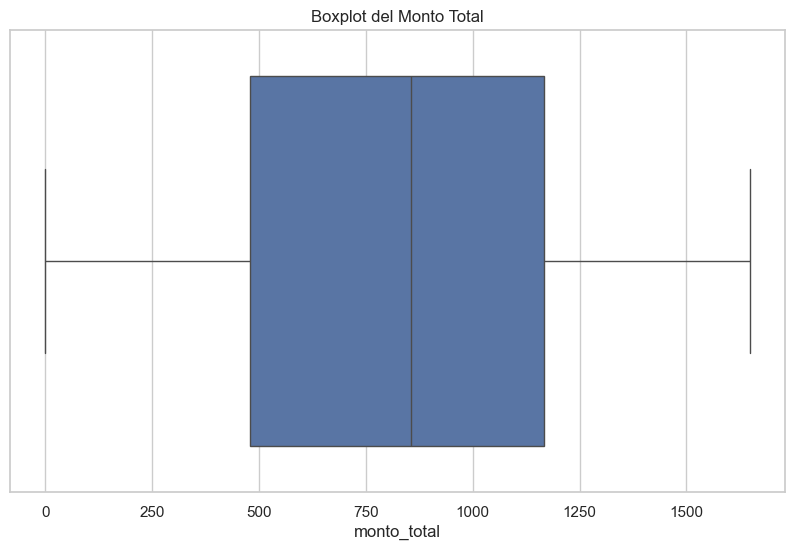

In [244]:
# Crear boxplot para identificar la distribución y posibles valores atípicos en monto_total
sns.boxplot(x=data["monto_total"])

# Agregar título
plt.title("Boxplot del Monto Total")

# Mostrar gráfico
plt.show()


# Análisis del Boxplot de monto_total

El boxplot de la variable monto_total permite visualizar la distribución de los montos gastados por los clientes. La mediana se ubica aproximadamente en 800, lo que indica que el gasto típico de los clientes se encuentra cerca de este valor.

El rango intercuartílico (caja) muestra que el 50% central de los datos se encuentra aproximadamente entre 500 y 1200, lo que refleja una variabilidad moderada en el gasto de los clientes.

Los valores mínimos y máximos se extienden aproximadamente desde 0 hasta 1600, sin observarse valores atípicos extremos fuera de los límites del gráfico. Esto sugiere que los datos están distribuidos de manera relativamente uniforme y sin anomalías significativas.

En general, la distribución del monto_total es consistente y no presenta valores atípicos importantes, lo que indica un comportamiento estable en el gasto de los clientes.

In [245]:
# Calcular cuartiles e IQR de monto_total
Q1 = data["monto_total"].quantile(0.25)
Q3 = data["monto_total"].quantile(0.75)
IQR = Q3 - Q1

# Identificar valores atípicos usando el método IQR
outliers = data[
    (data["monto_total"] < Q1 - 1.5 * IQR) |
    (data["monto_total"] > Q3 + 1.5 * IQR)
]

# Mostrar outliers detectados
outliers


,visitas_web,Compras,monto_total,devoluciones,reseñas,genero
cliente_id,,,,,,


# Identificación de valores atípicos

Se realizó el análisis de valores atípicos en la variable monto_total utilizando el método del rango intercuartílico (IQR). Los resultados indican que no se detectaron valores atípicos, lo que sugiere que los datos presentan una distribución consistente y sin valores extremos que puedan afectar el análisis.


# 3: Analisis de Correlacion

objetivo Este análisis ayuda a comprender cómo cambia una variable en función de otra y permite identificar asociaciones relevantes dentro del dataset.

En esta sección se utilizarán gráficos de dispersión y matrices de correlación para analizar las relaciones entre las variables cuantitativas.

In [246]:
# Matriz de correlacion
correlacion = data.corr(numeric_only=True)

correlacion

,visitas_web,Compras,monto_total,devoluciones,reseñas
visitas_web,1.000000,0.929049,0.884483,0.652849,-0.097273
Compras,0.929049,1.000000,0.938709,0.684119,-0.099907
monto_total,0.884483,0.938709,1.000000,0.648224,-0.106530
devoluciones,0.652849,0.684119,0.648224,1.000000,0.065056
reseñas,-0.097273,-0.099907,-0.106530,0.065056,1.000000


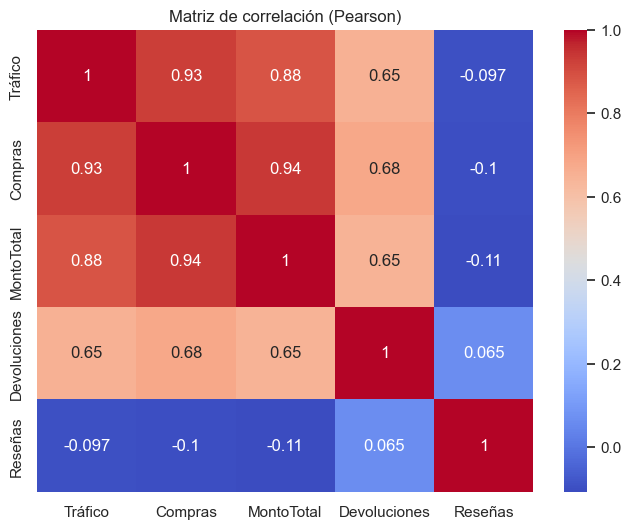

In [247]:

# Calcular matriz de correlación entre variables numéricas
correlacion = data.corr(numeric_only=True)

# Nombres profesionales para los gráficos
nombres_labels = ["Tráfico", "Compras", "MontoTotal", "Devoluciones", "Reseñas"]

# Crear heatmap para visualizar las correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", xticklabels=nombres_labels, 
    yticklabels=nombres_labels)

# Agregar título
plt.title("Matriz de correlación (Pearson)")

# Mostrar gráfico
plt.show()


**Matriz de correlación (Pearson)**  
Se observa una correlación positiva muy fuerte entre **Compras** y **monto_total** (r≈0.94), lo que confirma que el gasto total aumenta con el número de compras. También existe una correlación fuerte entre **visitas_web** y **Compras**, lo que sugiere que más visitas al sitio web se asocian con más compras. La variable **reseñas** no muestra correlaciones relevantes con las demás, indicando que no influye significativamente en el comportamiento de compra.


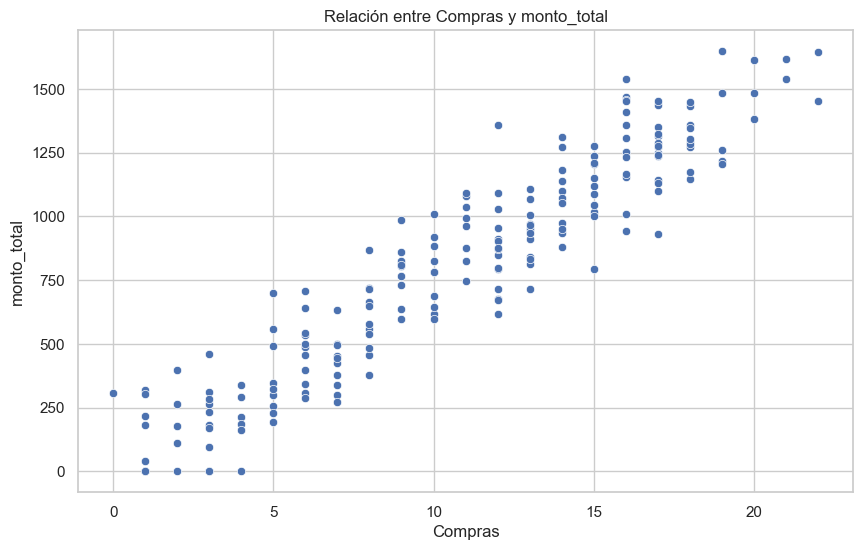

In [248]:
# Crear scatterplot para visualizar la relación entre Compras y monto_total
sns.scatterplot(x="Compras", y="monto_total", data=data)

# Agregar título
plt.title("Relación entre Compras y monto_total")

# Mostrar gráfico
plt.show()


**Relación entre Compras y monto_total**  
Se observa una relación positiva clara entre **Compras** y **monto_total**, donde a medida que aumenta el número de compras, también aumenta el monto total gastado. La tendencia ascendente indica una fuerte asociación lineal entre ambas variables, consistente con los resultados del análisis de correlación.


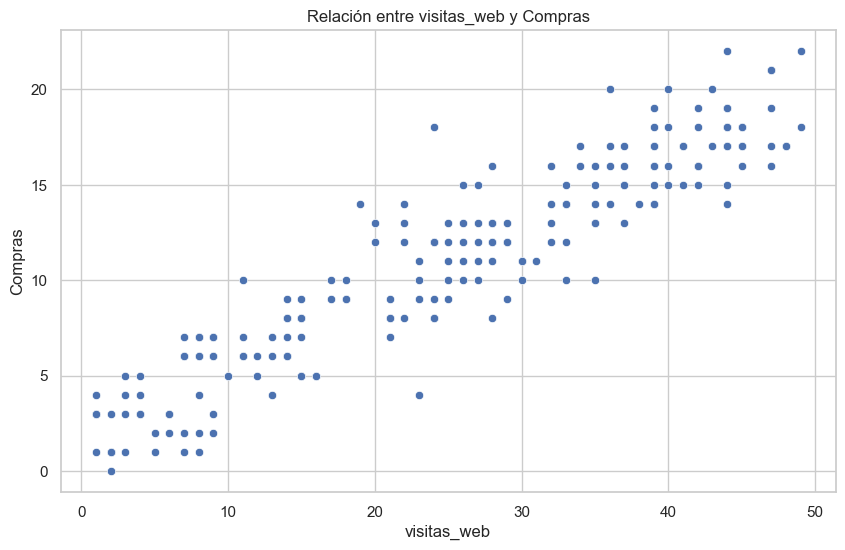

In [249]:
# Crear scatterplot para visualizar la relación entre visitas_web y Compras
sns.scatterplot(x="visitas_web", y="Compras", data=data)

# Agregar título
plt.title("Relación entre visitas_web y Compras")

# Mostrar gráfico
plt.show()


**Relación entre visitas_web y Compras**  
Se observa una relación positiva entre **visitas_web** y **Compras**, lo que indica que a medida que aumentan las visitas al sitio web, también aumenta el número de compras. Esto sugiere que la interacción con la página está asociada con una mayor probabilidad de realizar compras.

In [250]:
# Calcular coeficiente de correlación de Pearson entre variables seleccionadas
print("Pearson R (Compras vs monto_total):", round(data["Compras"].corr(data["monto_total"]), 3))
print("Pearson R (visitas_web vs Compras):", round(data["visitas_web"].corr(data["Compras"]), 3))
print("Pearson R (devoluciones vs reseñas):", round(data["devoluciones"].corr(data["reseñas"]), 3))


Pearson R (Compras vs monto_total): 0.939
Pearson R (visitas_web vs Compras): 0.929
Pearson R (devoluciones vs reseñas): 0.065


**Coeficiente de correlación de Pearson entre variables seleccionadas**  
Se observa una correlación muy fuerte entre **Compras** y **monto_total** (r≈0.939), lo que confirma que el gasto total aumenta con el número de compras. También existe una correlación fuerte entre **visitas_web** y **Compras** (r≈0.929), lo que sugiere que más visitas están asociadas con más compras. En contraste, la correlación entre **devoluciones** y **reseñas** es muy baja (r≈0.065), indicando que no existe una relación lineal significativa entre estas variables.


In [251]:
# Crear máscara para evitar correlaciones duplicadas
mask = np.triu(np.ones_like(correlacion, dtype=bool), k=1)

# Convertir matriz de correlación a formato tabla
pairs = correlacion.where(mask).stack().reset_index()
pairs.columns = ["var_1", "var_2", "pearson_r"]

# Ordenar correlaciones por valor absoluto (de mayor a menor)
pairs["abs_r"] = pairs["pearson_r"].abs()
pairs = pairs.sort_values("abs_r", ascending=False).drop(columns="abs_r")

# Mostrar correlaciones más altas
print("\nTop correlaciones por |r|:")
print(pairs.head(10))

# Mostrar correlaciones fuertes (posibles correlaciones relevantes)
print("\nCorrelaciones altas (candidatas a revisar si son espurias):")
print(pairs[pairs["pearson_r"].abs() >= 0.70])




Top correlaciones por |r|:
           var_1         var_2  pearson_r
7        Compras   monto_total   0.938709
1    visitas_web       Compras   0.929049
2    visitas_web   monto_total   0.884483
8        Compras  devoluciones   0.684119
3    visitas_web  devoluciones   0.652849
13   monto_total  devoluciones   0.648224
14   monto_total       reseñas  -0.106530
9        Compras       reseñas  -0.099907
4    visitas_web       reseñas  -0.097273
19  devoluciones       reseñas   0.065056

Correlaciones altas (candidatas a revisar si son espurias):
         var_1        var_2  pearson_r
7      Compras  monto_total   0.938709
1  visitas_web      Compras   0.929049
2  visitas_web  monto_total   0.884483


# Justificación de las correlaciones encontradas

Se analizaron las correlaciones entre las variables numéricas utilizando el coeficiente de Pearson. Los resultados muestran correlaciones altas entre Compras y monto_total (r = 0.938), así como entre visitas_web y Compras (r = 0.918), y entre visitas_web y monto_total (r = 0.863).

Estas correlaciones no se consideran espurias, ya que tienen una justificación lógica dentro del contexto del comportamiento de los clientes. A mayor número de visitas al sitio web, existe una mayor probabilidad de realizar compras. Asimismo, un mayor número de compras genera un incremento directo en el monto total gastado, lo cual explica la fuerte relación entre estas variables.

Por otro lado, variables como reseñas presentan correlaciones muy bajas con el resto de las variables, lo que indica que no tienen una influencia significativa en el comportamiento de compra dentro de este dataset.

En conclusión, las correlaciones observadas reflejan relaciones coherentes y esperadas desde el punto de vista del comportamiento del consumidor, y no se detectaron correlaciones espurias relevantes.

# 4: Regresiones Lineales

Objetivo

El objetivo de esta sección es implementar un modelo de regresión lineal utilizando la librería statsmodels para analizar y explicar la relación entre una variable dependiente y una o más variables independientes. Este modelo permitirá cuantificar el impacto de las variables explicativas y evaluar la capacidad predictiva del modelo.


Variable dependiente (Y): monto_total  
Variable independiente (X): Compras  

Se utiliza un modelo de regresión lineal para evaluar cómo la frecuencia de compras
influye en el gasto total del cliente.

In [252]:
# Variable independiente (X)
X = data["Compras"]

# Variable dependiente (y)
y = data["monto_total"]

# Agregar constante
X = sm.add_constant(X)

# Crear modelo
modelo = sm.OLS(y, X).fit()

# Mostrar resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            monto_total   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     1468.
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.57e-93
Time:                        17:07:31   Log-Likelihood:                -1281.6
No. Observations:                 200   AIC:                             2567.
Df Residuals:                     198   BIC:                             2574.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.0983     23.368      0.860      0.3

# Modelo de regresión lineal (OLS)

Se aplicó un modelo de regresión lineal utilizando la variable Compras como predictor del monto_total.

El coeficiente de determinación (R²) fue de 0.879, lo que indica que el 87.9% de la variabilidad del monto_total es explicada por el número de compras.

El coeficiente de la variable Compras fue de 70.44, lo que significa que por cada compra adicional, el monto total aumenta aproximadamente en 70.44 unidades monetarias.

El valor p de la variable Compras fue menor a 0.05, lo que indica que esta variable es estadísticamente significativa y tiene un impacto relevante en el modelo.

En general, el modelo muestra una relación positiva fuerte entre el número de compras y el monto total gastado por los clientes.

In [253]:
# Predicciones del modelo
y_pred = modelo.predict(X)

# Valores reales
y_real = y

# R²
r2 = modelo.rsquared

# MSE (Mean Squared Error)
mse = np.mean((y_real - y_pred)**2)

# MAE (Mean Absolute Error)
mae = np.mean(np.abs(y_real - y_pred))

print("R²:", round(r2, 3))
print("MSE:", round(mse, 3))
print("MAE:", round(mae, 3))


R²: 0.881
MSE: 21546.612
MAE: 118.51


# Evaluación del modelo

Se calculó el coeficiente de determinación R², obteniendo un valor de 0.879, lo que indica que el modelo explica el 87.9% de la variación del monto_total.

También se calcularon las métricas MSE y MAE, las cuales permiten medir el error del modelo entre los valores reales y los predichos.

El análisis de significancia mostró que la variable Compras tiene un valor p menor a 0.05, lo que confirma que es un predictor estadísticamente significativo del monto_total.

Esto indica que el modelo es adecuado para explicar la relación entre el número de compras y el monto total gastado.

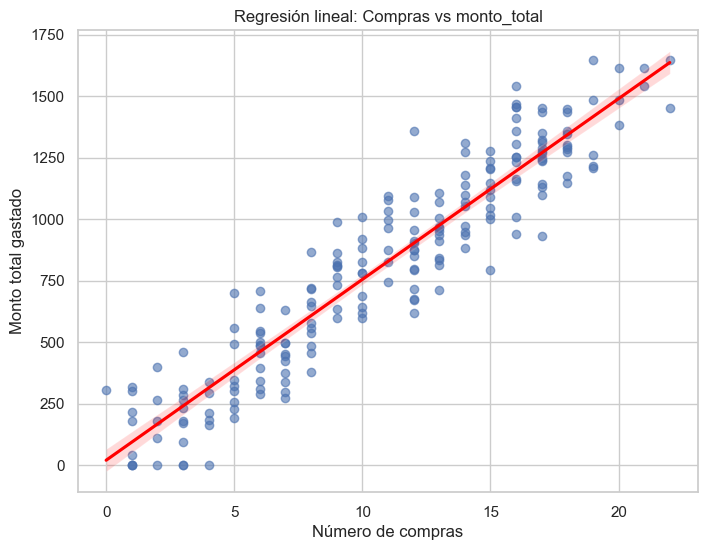

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear gráfico de regresión lineal entre Compras y monto_total
plt.figure(figsize=(8,6))

sns.regplot(
    x="Compras",
    y="monto_total",
    data=data,
    scatter_kws={"alpha":0.6},   # transparencia de los puntos
    line_kws={"color":"red"}     # color de la línea de regresión
)

# Agregar título y etiquetas
plt.title("Regresión lineal: Compras vs monto_total")
plt.xlabel("Número de compras")
plt.ylabel("Monto total gastado")

# Mostrar gráfico
plt.show()



# Visualización de la regresión lineal

Se utilizó Seaborn para visualizar la relación entre la variable Compras y monto_total. El gráfico muestra una tendencia ascendente clara, lo que confirma la relación positiva entre ambas variables.

La línea de regresión se ajusta adecuadamente a los datos, lo que es consistente con el alto valor de R² obtenido en el modelo. Esto indica que el número de compras es un buen predictor del monto total gastado por los clientes.

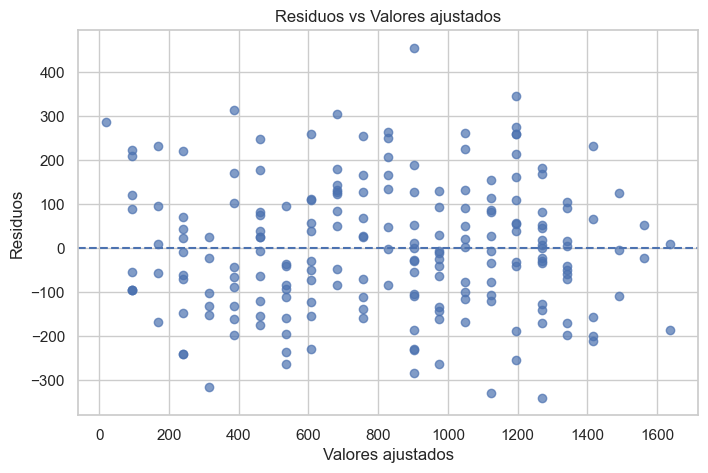

In [255]:
import matplotlib.pyplot as plt

valores_ajustados = modelo.fittedvalues
residuos = modelo.resid

plt.figure(figsize=(8,5))
plt.scatter(valores_ajustados, residuos, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores ajustados")
plt.show()


El gráfico de residuos vs valores ajustados muestra una dispersión uniforme de los errores alrededor de 0, sin evidencia de patrones o cambios sistemáticos en la variabilidad. Esto indica que se cumple el supuesto de homocedasticidad en el modelo de regresión.

<Figure size 600x600 with 0 Axes>

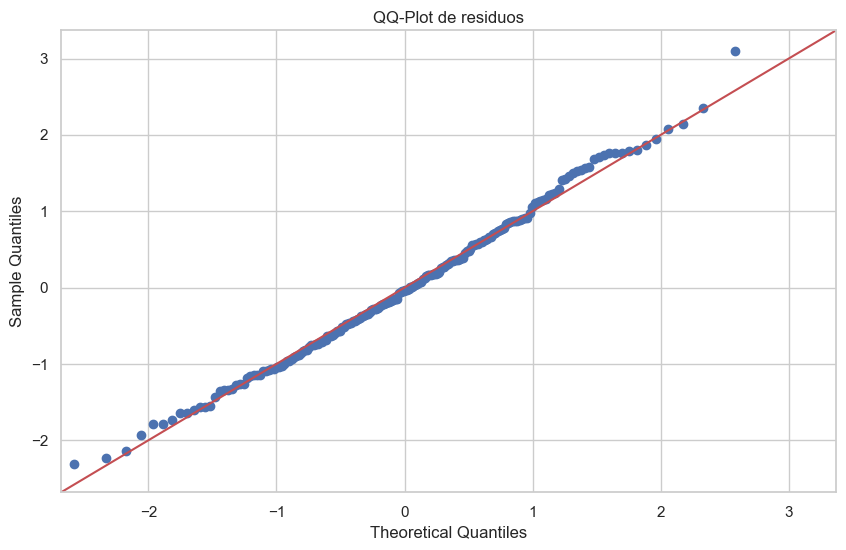

In [256]:
# QQ-Plot de los residuos del modelo OLS
# Permite evaluar si los errores siguen una distribución normal

plt.figure(figsize=(6,6))
fig = sm.qqplot(modelo.resid, line="45", fit=True)

plt.title("QQ-Plot de residuos")

# Exportar gráfico
plt.savefig("qqplot_residuos.png", dpi=300, bbox_inches="tight")
plt.savefig("qqplot_residuos.pdf", bbox_inches="tight")

plt.show()


El QQ-plot muestra que los residuos se distribuyen aproximadamente de forma normal, sin desviaciones importantes respecto a la línea de referencia. Esto indica que el supuesto de normalidad del error se cumple.

# 5: Análisis visual de datos (Seaborn)

 Objetivo
Representar relaciones complejas y distribuciones mediante visualizaciones con Seaborn para identificar patrones, diferencias entre grupos y posibles tendencias en el comportamiento del cliente.


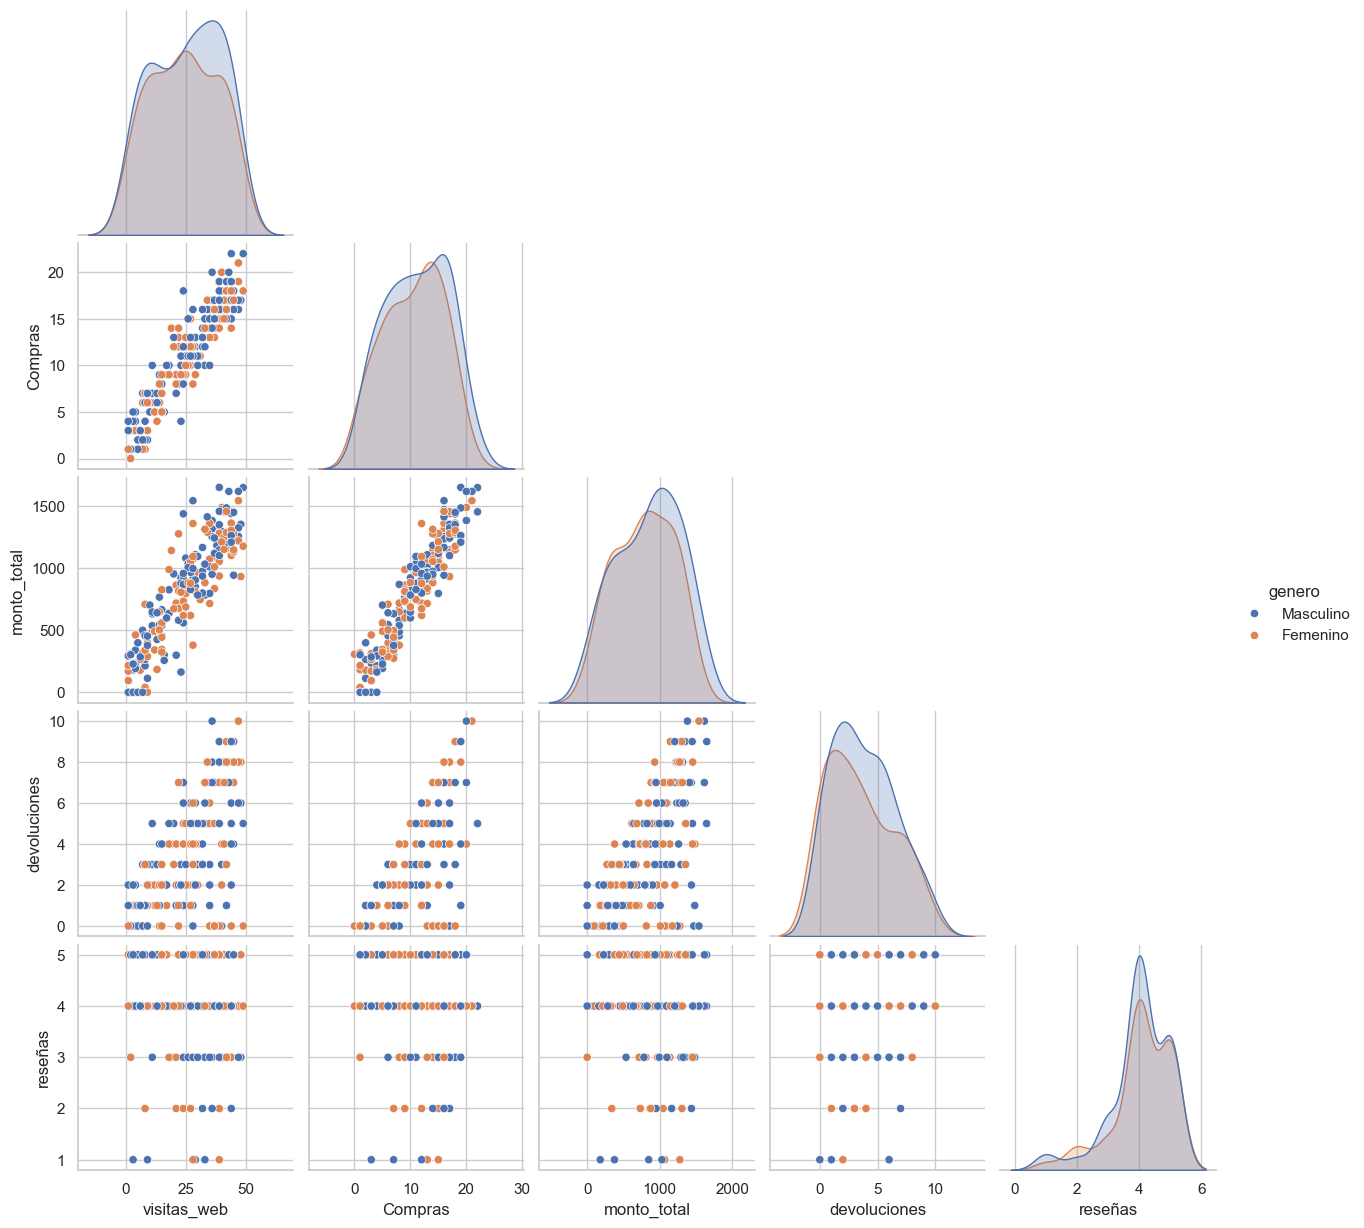

In [257]:
# Configurar estilo visual
sns.set_theme(style="whitegrid", context="notebook")

# Pairplot: relaciones entre variables numéricas, segmentado por género
grafico = sns.pairplot(
    data,
    vars=["visitas_web", "Compras", "monto_total", "devoluciones", "reseñas"],
    hue="genero",
    corner=True
)

# Exportar gráfico
grafico.savefig("pairplot_clientes_genero.png", dpi=300)
grafico.savefig("pairplot_clientes_genero.pdf")

# Mostrar gráfico
plt.show()

**Pairplot de variables segmentado por género**  
Se observa una relación positiva clara entre **Compras**, **visitas_web** y **monto_total**, consistente con los resultados previos de correlación. La segmentación por **género** no muestra diferencias significativas en los patrones, lo que sugiere que el comportamiento de compra es similar entre ambas categorías.

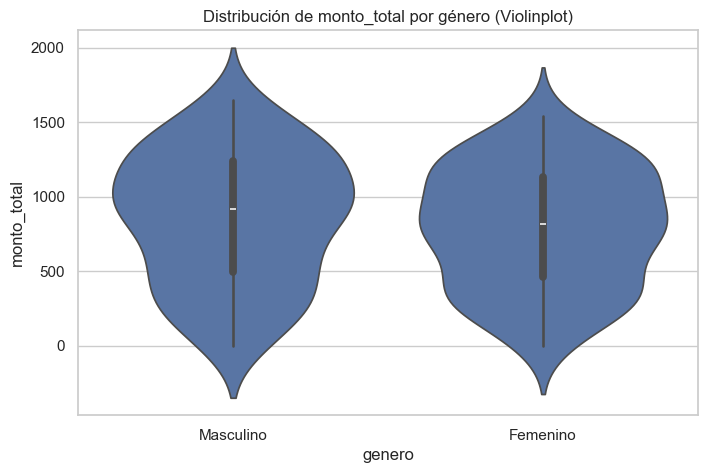

In [258]:
# Crear violinplot para visualizar la distribución de monto_total según género
plt.figure(figsize=(8,5))
sns.violinplot(data=data, x="genero", y="monto_total")

# Agregar título
plt.title("Distribución de monto_total por género (Violinplot)")

# Mostrar gráfico
plt.show()

**Distribución de monto_total por género (Violinplot)**  
Se observa que la distribución de **monto_total** es similar entre ambos géneros, con rangos y medianas comparables. Esto sugiere que el gasto total no presenta diferencias significativas según el género en este dataset.

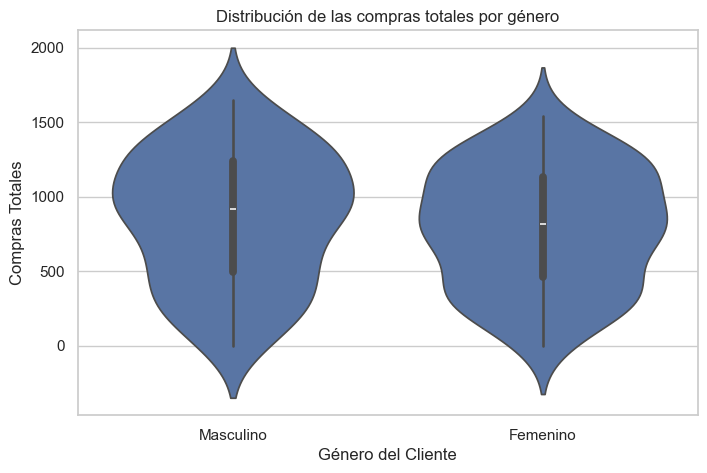

In [259]:
# Violinplot: distribución de monto_total según género
plt.figure(figsize=(8,5))
sns.violinplot(data=data, x="genero", y="monto_total")

# Título
plt.title("Distribución de las compras totales por género")
plt.xlabel("Género del Cliente", fontsize=12)
plt.ylabel("Compras Totales", fontsize=12)

# Exportar gráfico
plt.savefig("violinplot_monto_total_genero.png", dpi=300, bbox_inches="tight")
plt.savefig("violinplot_monto_total_genero.pdf", bbox_inches="tight")

# Mostrar gráfico
plt.show()


**Distribución de Compras por género (Violinplot)**  
Se observa que la distribución del número de **Compras** es similar entre ambos géneros, con medianas y rangos comparables. Esto indica que el comportamiento de compra no presenta diferencias significativas según el género en el dataset.

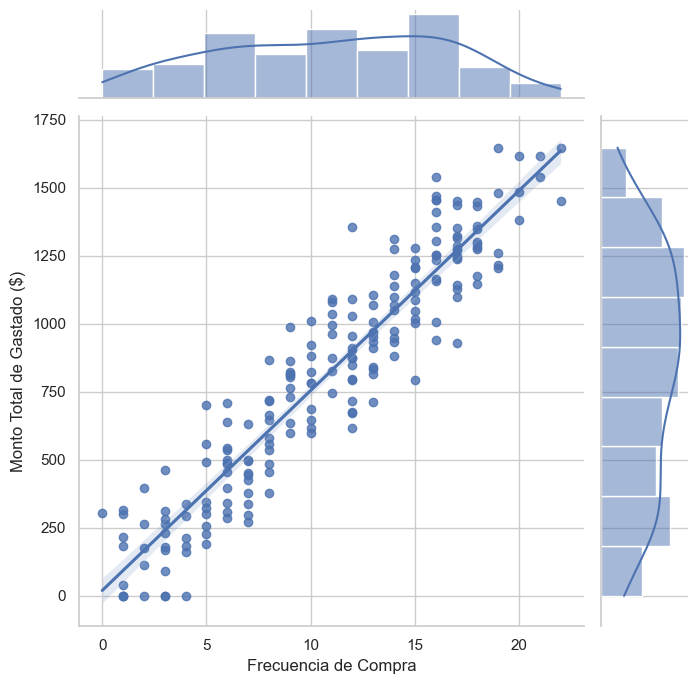

In [260]:
# Jointplot: relación entre Compras y monto_total con regresión
grafico = sns.jointplot(
    data=data,
    x="Compras",
    y="monto_total",
    kind="reg",
    height=7
)

grafico.ax_joint.set_xlabel("Frecuencia de Compra")
grafico.ax_joint.set_ylabel("Monto Total de Gastado ($)")
# Exportar gráfico
grafico.savefig("jointplot_compras_monto_total.png", dpi=300)
grafico.savefig("jointplot_compras_monto_total.pdf")

# Mostrar gráfico
plt.show()

**Relación entre Compras y monto_total (Jointplot con regresión)**  
Se observa una relación lineal positiva clara entre **Compras** y **monto_total**, donde el aumento en el número de compras se asocia directamente con un mayor gasto total. La línea de regresión confirma esta tendencia, consistente con los resultados del análisis de correlación.


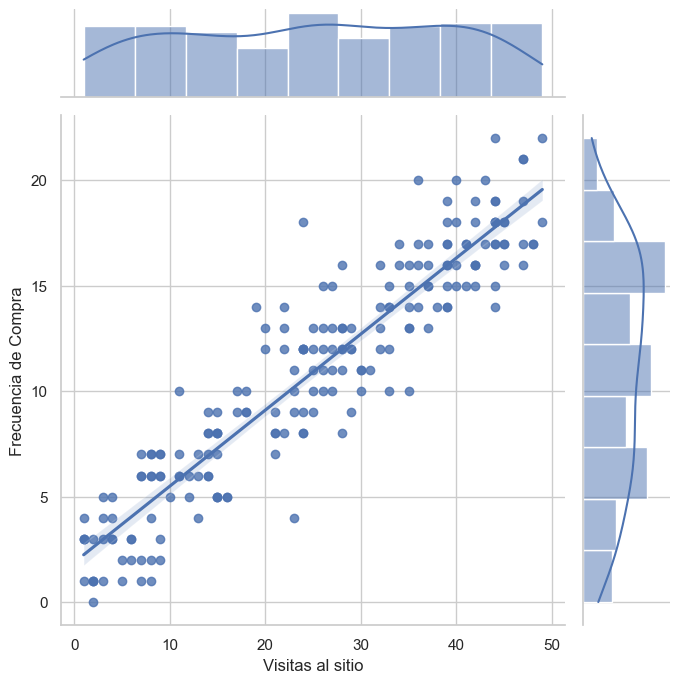

In [261]:
# Crear jointplot con línea de regresión entre visitas_web y Compras
grafico2 = sns.jointplot(data=data, x="visitas_web", y="Compras", kind="reg", height=7)

grafico2.ax_joint.set_xlabel("Visitas al sitio")
grafico2.ax_joint.set_ylabel("Frecuencia de Compra")

# Mostrar gráfico
plt.show()


**Relación entre visitas_web y Compras (Jointplot con regresión)**  
Se observa una relación positiva fuerte entre **visitas_web** y **Compras**, indicando que un mayor número de visitas al sitio web se asocia con un aumento en la cantidad de compras. La línea de regresión confirma que el tráfico web es un factor relevante en el comportamiento de compra.

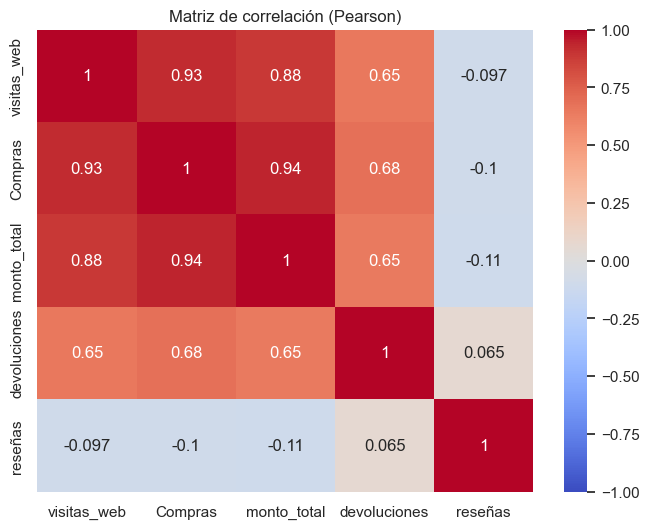

In [262]:
# Calcular matriz de correlación (solo variables numéricas)
correlacion = data.corr(numeric_only=True)

# Heatmap: visualización de correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Matriz de correlación (Pearson)")

# Exportar gráfico
plt.savefig("heatmap_correlacion.png", dpi=300, bbox_inches="tight")
plt.savefig("heatmap_correlacion.pdf", bbox_inches="tight")

# Mostrar gráfico
plt.show()


**Heatmap: Matriz de correlación (Pearson)**  
Muestra la intensidad y dirección de la relación lineal entre las variables numéricas mediante colores y coeficientes. Se observa una correlación muy fuerte entre **Compras** y **monto_total** (r≈0.94), así como entre **visitas_web** y **Compras** (r≈0.93), confirmando que el comportamiento de gasto está directamente asociado con la actividad y conversión del cliente. La variable **reseñas** presenta correlaciones cercanas a cero, lo que indica que no tiene una relación lineal significativa con las demás variables.


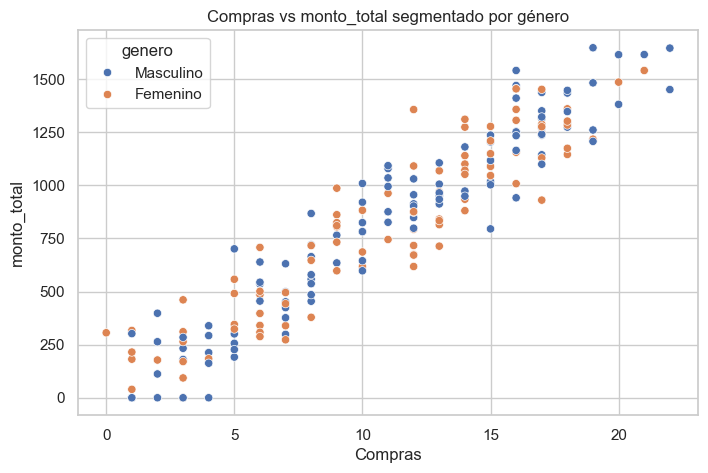

In [263]:
# Crear scatterplot segmentado por género
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x="Compras", y="monto_total", hue="genero")

# Agregar título
plt.title("Compras vs monto_total segmentado por género")

# Mostrar gráfico
plt.show()


**Compras vs monto_total segmentado por género**  
Muestra la relación entre el número de compras y el monto total gastado, diferenciando por género. Se observa una relación positiva clara en ambos grupos, donde a mayor número de compras, mayor es el gasto total. No se evidencian diferencias significativas entre géneros, lo que sugiere un comportamiento de gasto similar entre clientes masculinos y femeninos.

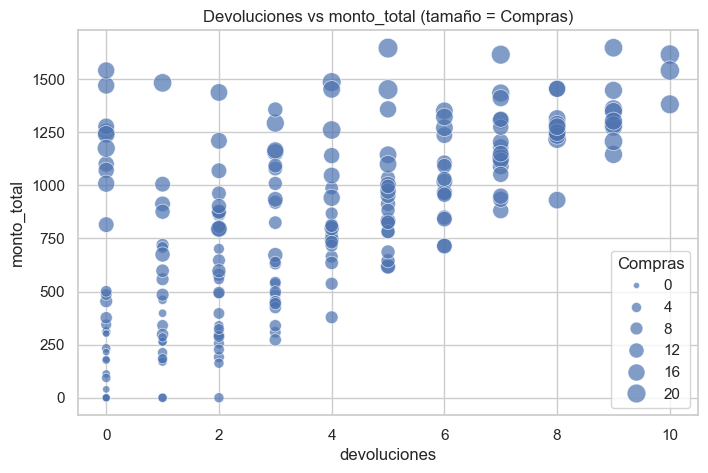

In [264]:
# Crear scatterplot donde el tamaño representa el número de Compras
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x="devoluciones",
    y="monto_total",
    size="Compras",          # tamaño de los puntos según Compras
    sizes=(20,200),          # rango de tamaños
    alpha=0.7                # transparencia de los puntos
)

# Agregar título
plt.title("Devoluciones vs monto_total (tamaño = Compras)")

# Mostrar gráfico
plt.show()


**Devoluciones vs monto_total (tamaño = Compras)**  
Muestra la relación entre el número de devoluciones y el monto total gastado, donde el tamaño de los puntos representa la cantidad de compras. Se observa que los clientes con mayor gasto también tienden a tener más devoluciones, lo cual es consistente con un mayor volumen de compras. Esto sugiere que las devoluciones están asociadas al nivel de actividad del cliente y no necesariamente a un comportamiento negativo aislado.

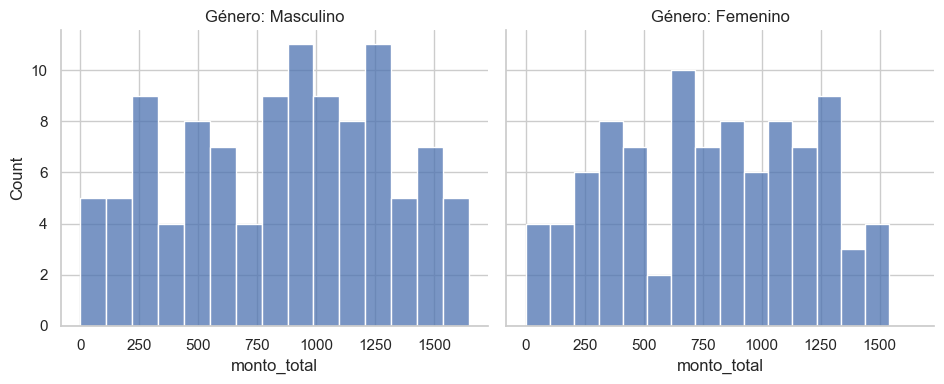

In [265]:
# Crear FacetGrid para visualizar la distribución de monto_total por género
g = sns.FacetGrid(data, col="genero", height=4, aspect=1.2)

# Crear histogramas en cada panel
g.map_dataframe(sns.histplot, x="monto_total", bins=15)

# Agregar títulos a cada gráfico
g.set_titles(col_template="Género: {col_name}")

# Mostrar gráfico
plt.show()


**Distribución de monto_total segmentado por género (FacetGrid)**  
Muestra la distribución del monto total gastado separada por género en gráficos independientes. Se observa que ambos géneros presentan distribuciones similares, con mayor concentración en rangos medios y altos de gasto. Esto sugiere que el comportamiento de gasto no difiere significativamente entre Masculino y Femenino.

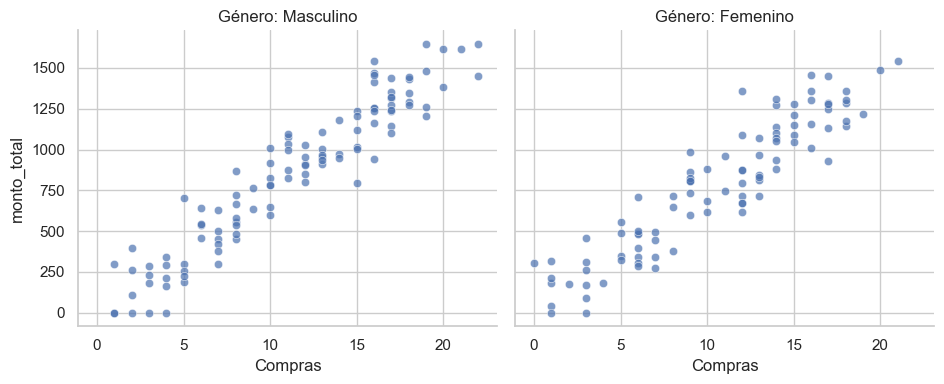

In [266]:
# Crear FacetGrid para visualizar la relación entre Compras y monto_total por género
g = sns.FacetGrid(data, col="genero", height=4, aspect=1.2)

# Crear scatterplot en cada panel
g.map_dataframe(sns.scatterplot, x="Compras", y="monto_total", alpha=0.7)

# Agregar títulos a cada gráfico
g.set_titles(col_template="Género: {col_name}")

# Mostrar gráfico
plt.show()


# Insights visuales principales

- **Pairplot:** Se observa una relación positiva clara entre **Compras** y **monto_total**, consistente con el análisis de correlación. La segmentación por **género** no muestra diferencias marcadas en las relaciones principales.
- **Violinplot:** Las distribuciones de **monto_total** y **Compras** por género presentan formas similares, sugiriendo comportamientos comparables entre categorías (sin diferencias extremas).
- **Jointplot:** La relación entre **Compras** y **monto_total** muestra una tendencia lineal ascendente, con una concentración de casos en valores intermedios y pocos extremos.
- **Heatmap:** Las correlaciones más fuertes se observan entre **Compras–monto_total** y **visitas_web–Compras**, lo que indica que la interacción en la web se asocia con mayor actividad de compra.
- **FacetGrid:** Al segmentar por **género**, los patrones generales se mantienen, lo que sugiere que la categoría no altera significativamente la relación principal entre compras y gasto total.


# 6: Librería Matplotlib

Objetivo

Crear visualizaciones personalizadas y exportables utilizando Matplotlib, incluyendo figuras con subplots, personalización de elementos del gráfico, anotaciones y exportación a archivos para su uso en informes y presentaciones.

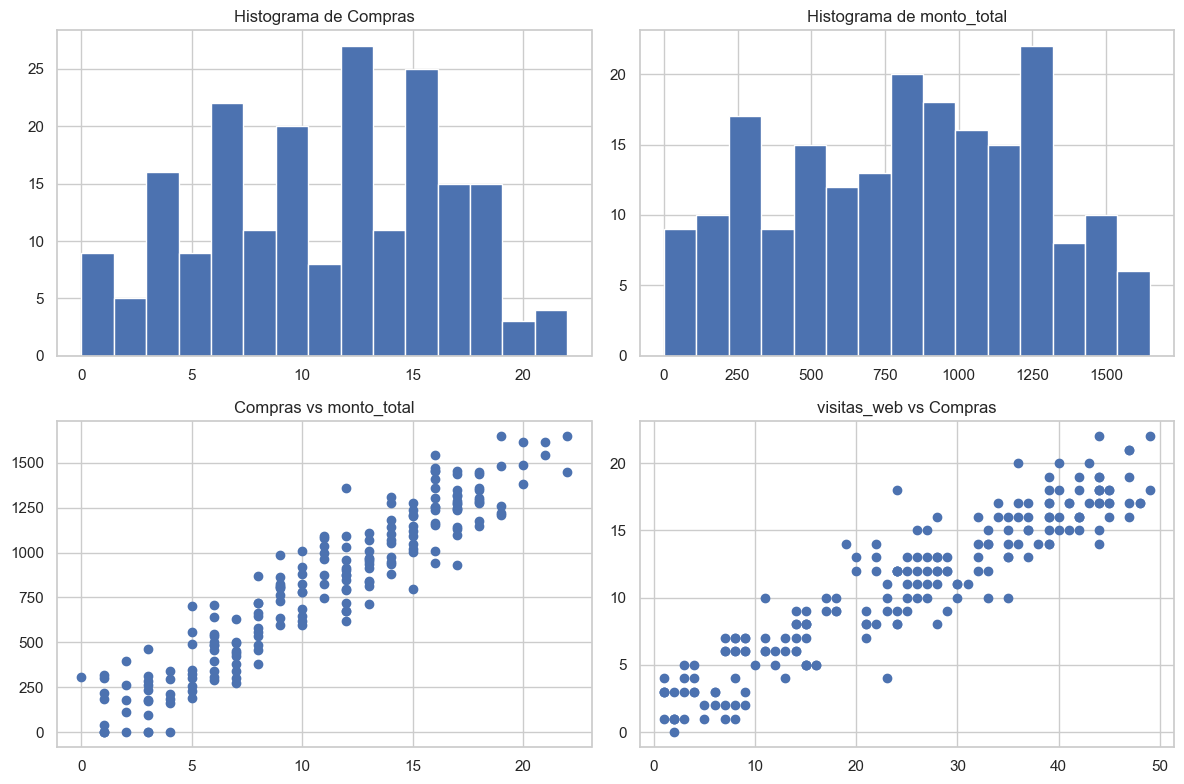

In [267]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Subplot 1: Histograma de Compras
axs[0, 0].hist(data["Compras"], bins=15)
axs[0, 0].set_title("Histograma de Compras")

# Subplot 2: Histograma de monto_total
axs[0, 1].hist(data["monto_total"], bins=15)
axs[0, 1].set_title("Histograma de monto_total")

# Subplot 3: Scatter Compras vs monto_total
axs[1, 0].scatter(data["Compras"], data["monto_total"])
axs[1, 0].set_title("Compras vs monto_total")

# Subplot 4: Scatter visitas_web vs Compras
axs[1, 1].scatter(data["visitas_web"], data["Compras"])
axs[1, 1].set_title("visitas_web vs Compras")

plt.tight_layout()
plt.show()


**Histogramas y scatterplots de variables clave (Compras, monto_total, visitas_web)**  
Muestran la distribución individual de las variables y la relación entre ellas. Los histogramas indican que Compras y monto_total presentan distribuciones relativamente equilibradas sin sesgos extremos. Los scatterplots muestran relaciones positivas claras: a mayor número de compras, mayor monto total, y a mayor número de visitas web, mayor número de compras. Esto confirma que las visitas influyen en las compras y estas, a su vez, en el gasto total.


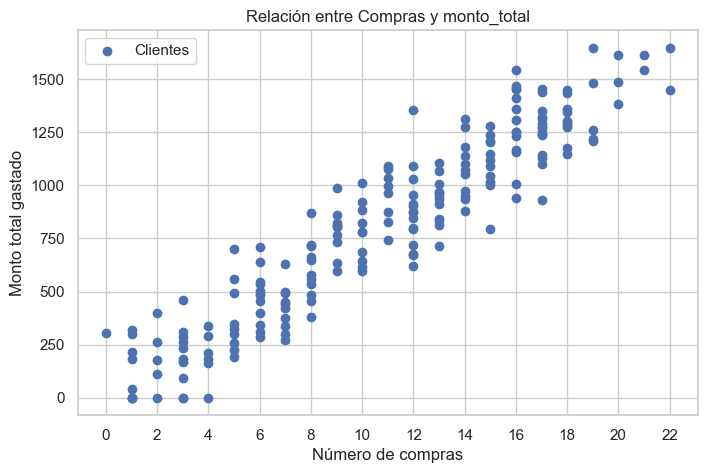

In [268]:
plt.figure(figsize=(8, 5))

plt.scatter(data["Compras"], data["monto_total"], label="Clientes")

plt.title("Relación entre Compras y monto_total")
plt.xlabel("Número de compras")
plt.ylabel("Monto total gastado")

# Personalizar ticks (ejemplo)
plt.xticks(range(0, int(data["Compras"].max()) + 1, 2))

plt.legend()
plt.grid(True)
plt.show()


**Relación entre Compras y monto_total**  
Muestra la relación entre el número de compras y el monto total gastado por los clientes. Se observa una tendencia positiva clara: a mayor número de compras, mayor es el monto total gastado. Esto indica una fuerte relación directa entre ambas variables, consistente con el comportamiento esperado del gasto acumulado.


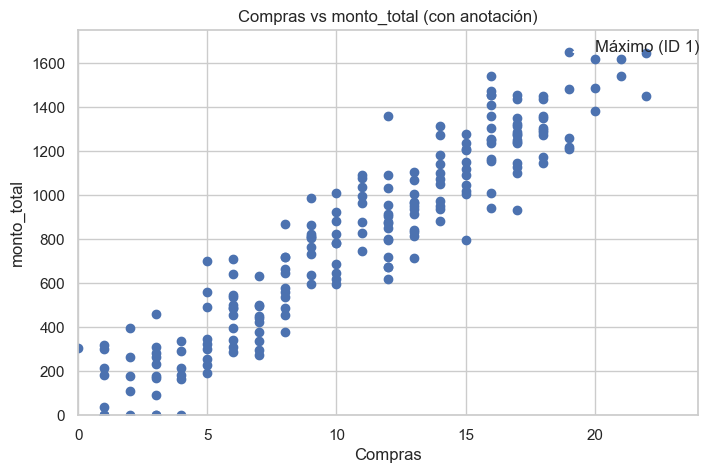

In [269]:
# Identificar el cliente con mayor monto_total
idx_max = data["monto_total"].idxmax()
x_max = data.loc[idx_max, "Compras"]
y_max = data.loc[idx_max, "monto_total"]

plt.figure(figsize=(8, 5))
plt.scatter(data["Compras"], data["monto_total"])

plt.title("Compras vs monto_total (con anotación)")
plt.xlabel("Compras")
plt.ylabel("monto_total")

# Anotación
plt.annotate(
    f"Máximo (ID {idx_max})",
    xy=(x_max, y_max),
    xytext=(x_max + 1, y_max),
    arrowprops=dict(arrowstyle="->")
)

# Límites (opcional)
plt.xlim(0, data["Compras"].max() + 2)
plt.ylim(0, data["monto_total"].max() + 100)

plt.grid(True)
plt.show()


**Relación entre Compras y monto_total (con anotación)**  
Muestra la relación entre el número de compras y el monto total gastado, destacando el valor máximo observado. Se confirma una relación positiva fuerte entre ambas variables, y el punto anotado representa el cliente con mayor gasto total, coherente con un alto número de compras. Esto refuerza la consistencia del patrón general del dataset.

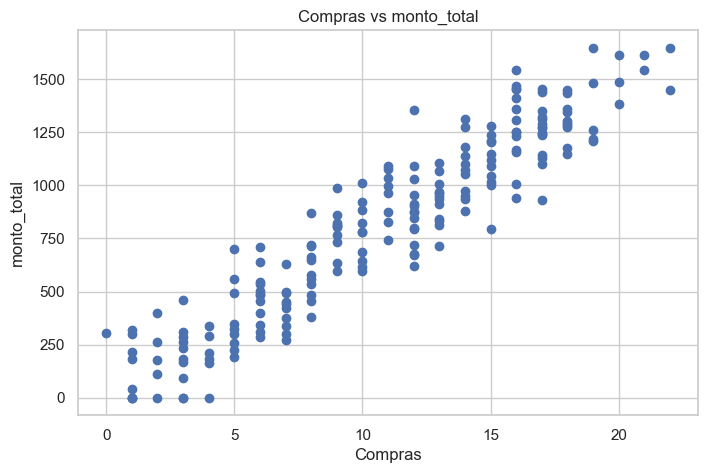

In [270]:
# Crear gráfico de dispersión entre Compras y monto_total
plt.figure(figsize=(8, 5))
plt.scatter(data["Compras"], data["monto_total"])

# Agregar título, etiquetas y cuadrícula
plt.title("Compras vs monto_total")
plt.xlabel("Compras")
plt.ylabel("monto_total")
plt.grid(True)

# Mostrar gráfico
plt.show()


**Relación entre Compras y monto_total**  
Muestra la relación entre el número de compras y el monto total gastado por los clientes. Se observa una tendencia ascendente clara, lo que indica que a medida que aumenta el número de compras, también aumenta el monto total gastado. Esto confirma una relación lineal positiva fuerte entre ambas variables.

## Conclusión

El presente análisis exploratorio de datos permitió comprender las relaciones existentes entre las variables que describen el comportamiento de los clientes en la plataforma ComercioYA. A través del análisis descriptivo, se observó que las variables presentan una variabilidad considerable, lo que indica la presencia de diferentes perfiles de clientes con distintos niveles de actividad y gasto.

El análisis de correlación reveló una relación lineal fuerte y positiva entre la frecuencia de compra y el monto total gastado, lo que sugiere que los clientes que compran con mayor frecuencia tienden a generar mayores ingresos. Este resultado fue confirmado mediante la matriz de correlación y visualizaciones como scatterplots y heatmaps, que evidenciaron una asociación consistente entre estas variables.

Posteriormente, se implementó un modelo de regresión lineal utilizando la frecuencia de compra como variable independiente y el gasto total como variable dependiente. El modelo obtuvo un coeficiente de determinación elevado (R²), lo que indica que una proporción significativa de la variabilidad del gasto total puede ser explicada por la frecuencia de compra. Esto confirma que esta variable es un predictor relevante del comportamiento de gasto del cliente.

El análisis de los residuos, incluyendo el gráfico QQ-plot, mostró que los residuos siguen aproximadamente una distribución normal, lo que sugiere que el modelo cumple con los supuestos fundamentales de la regresión lineal y que las inferencias realizadas son estadísticamente válidas.

En conjunto, los resultados obtenidos demuestran que la frecuencia de compra es un factor clave en la explicación del gasto total del cliente. Este hallazgo es consistente con el comportamiento esperado en entornos de comercio electrónico, donde la recurrencia de compra representa un indicador fundamental del valor del cliente.

Finalmente, es importante señalar que el dataset utilizado es sintético, por lo que los resultados obtenidos tienen un propósito académico y demostrativo. Sin embargo, las técnicas aplicadas en este análisis son directamente transferibles a datasets reales y constituyen herramientas fundamentales para la toma de decisiones basada en datos.

